In [28]:
import pandas as pd

In [29]:
df1 = pd.read_csv('BACI/BACI_HS12_Y2013_V202601.csv')
df2 = pd.read_csv('BACI/BACI_HS12_Y2014_V202601.csv')
df3 = pd.read_csv('BACI/BACI_HS12_Y2015_V202601.csv')
df4 = pd.read_csv('BACI/BACI_HS12_Y2016_V202601.csv')
df5 = pd.read_csv('BACI/BACI_HS12_Y2017_V202601.csv')
df6 = pd.read_csv('BACI/BACI_HS12_Y2018_V202601.csv')
df7 = pd.read_csv('BACI/BACI_HS12_Y2019_V202601.csv')
df8 = pd.read_csv('BACI/BACI_HS12_Y2020_V202601.csv')
df9 = pd.read_csv('BACI/BACI_HS12_Y2021_V202601.csv')
df10 = pd.read_csv('BACI/BACI_HS12_Y2022_V202601.csv')
df11 = pd.read_csv('BACI/BACI_HS12_Y2023_V202601.csv')

In [30]:
import pandas as pd

# Store dataframes in chronological order
dfs = [
    df1, df2, df3, df4, df5,
    df6, df7, df8, df9, df10, df11
]

# Concatenate
baci_panel = pd.concat(dfs, ignore_index=True)

# Optional: verify structure
print(baci_panel.shape)
print(baci_panel.head())

(121990886, 6)
      t  i   j       k      v      q
0  2013  4   8  401519  2.952  0.342
1  2013  4   8  630900  1.799  0.023
2  2013  4  12  611020  0.181  0.005
3  2013  4  20   40610  1.895  0.342
4  2013  4  20  570242  2.660  0.008


In [31]:
target_importers = [156, 699, 586, 398]

df_filtered = baci_panel[
    baci_panel['i'].isin(target_importers)
]

In [32]:
df_filtered

,t,i,j,k,v,q
1255492,2013,156,4,20714,6349.097,2671.600
1255493,2013,156,4,51199,23.518,0.064
1255494,2013,156,4,70960,0.300,0.600
1255495,2013,156,4,90210,302.977,134.560
1255496,2013,156,4,90220,5198.501,1945.090
...,...,...,...,...,...,...
118761667,2023,699,894,961800,3.024,0.556
118761668,2023,699,894,961900,185.125,26.533
118761669,2023,699,894,970190,0.084,0.001
118761670,2023,699,894,970300,15.260,0.554


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Copy your merged BACI panel
df = baci_panel.copy()

# Drop accidental index column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Keep only 4 importers
target_importers = [156, 699, 586, 398]
df = df[df['i'].isin(target_importers)].copy()

# Country labels
country_map = {
    156: 'China',
    699: 'India',
    586: 'Pakistan',
    398: 'Kazakhstan'
}

df['importer_name'] = df['i'].map(country_map)

# Make sure product code is 6-digit string
df['k'] = df['k'].astype(str).str.zfill(6)

# HS2 code
df['hs2'] = df['k'].str[:2]

# Basic check
print(df[['t', 'i', 'importer_name', 'j', 'k', 'hs2', 'v']].head())
print(df.shape)

            t    i importer_name  j       k hs2         v
1255492  2013  156         China  4  020714  02  6349.097
1255493  2013  156         China  4  051199  05    23.518
1255494  2013  156         China  4  070960  07     0.300
1255495  2013  156         China  4  090210  09   302.977
1255496  2013  156         China  4  090220  09  5198.501
(10240508, 8)


In [34]:
df.to_csv('BACI panel.csv', index=False)

In [8]:
annual_imports = (
    df.groupby(['t', 'importer_name'], as_index=False)['v']
      .sum()
      .rename(columns={'v': 'total_imports'})
)

print(annual_imports.head(12))

       t importer_name  total_imports
0   2013         China   2.333043e+09
1   2013         India   3.161097e+08
2   2013    Kazakhstan   7.439932e+07
3   2013      Pakistan   2.850736e+07
4   2014         China   2.461471e+09
5   2014         India   3.198251e+08
6   2014    Kazakhstan   6.829985e+07
7   2014      Pakistan   2.939796e+07
8   2015         China   2.424570e+09
9   2015         India   2.799710e+08
10  2015    Kazakhstan   4.449584e+07
11  2015      Pakistan   2.666221e+07


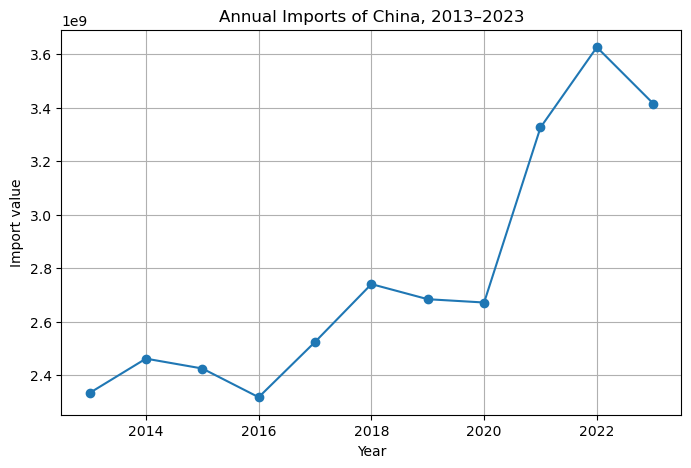

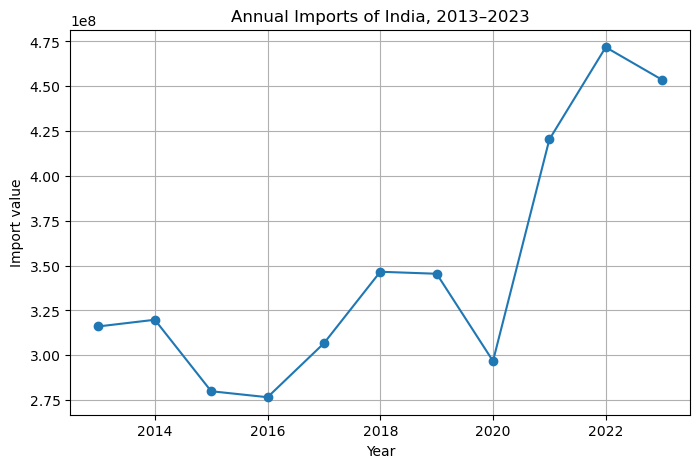

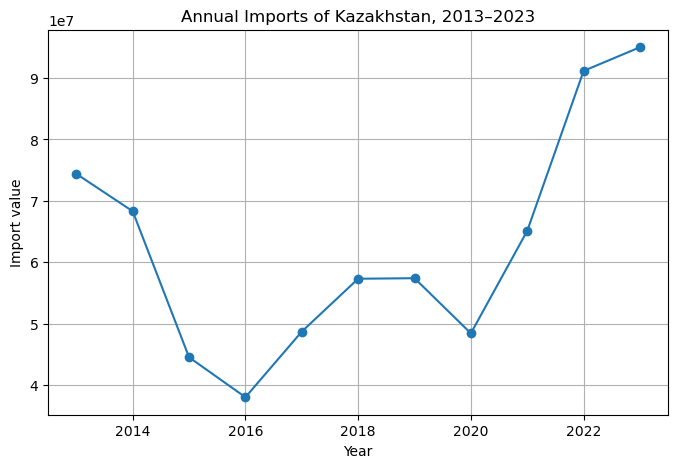

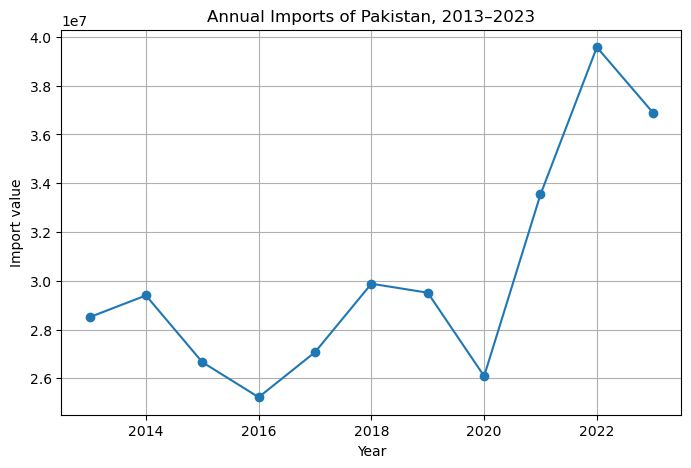

In [9]:
for country in annual_imports['importer_name'].unique():
    temp = annual_imports[annual_imports['importer_name'] == country]
    plt.figure(figsize=(8, 5))
    plt.plot(temp['t'], temp['total_imports'], marker='o')
    plt.title(f'Annual Imports of {country}, 2013–2023')
    plt.xlabel('Year')
    plt.ylabel('Import value')
    plt.grid(True)
    plt.show()

In [14]:
# Ensure HS6 is string and derive HS2
df['k'] = df['k'].astype(str).str.zfill(6)
df['hs2'] = df['k'].str[:2]

# Aggregate imports by importer-year-HS2
hs2_imports = (
    df.groupby(['t', 'importer_name', 'hs2'], as_index=False)['v']
      .sum()
      .rename(columns={'v': 'imports_hs2'})
)

print(hs2_imports.head())

      t importer_name hs2   imports_hs2
0  2013         China  01  6.167882e+05
1  2013         China  02  8.918861e+05
2  2013         China  03  1.024553e+07
3  2013         China  04  5.290464e+05
4  2013         China  05  1.970651e+06


In [15]:
# Make sure HS6 is string and derive HS2
df['k'] = df['k'].astype(str).str.zfill(6)
df['hs2'] = df['k'].str[:2]

# Aggregate
hs2_imports = (
    df.groupby(['t', 'importer_name', 'hs2'], as_index=False)['v']
      .sum()
      .rename(columns={'v': 'imports_hs2'})
)

In [16]:
hs2_imports = hs2_imports.sort_values(
    by=['importer_name', 'hs2', 't']
)

In [17]:
hs2_imports['imports_hs2'] = hs2_imports['imports_hs2'].round(2)

In [18]:
hs2_imports.to_excel('hs2_imports_chronological.xlsx', index=False)

# Statistics


In [20]:
annual_imports = (
    df.groupby(['t', 'importer_name'], as_index=False)['v']
      .sum()
      .rename(columns={'v': 'total_imports'})
)

annual_imports['total_imports_bln'] = annual_imports['total_imports'] / 1e9

In [21]:
base = annual_imports[annual_imports['t'] == 2013][['importer_name', 'total_imports']]
base = base.rename(columns={'total_imports': 'base_2013'})

annual_imports = annual_imports.merge(base, on='importer_name')
annual_imports['index'] = annual_imports['total_imports'] / annual_imports['base_2013'] * 100

AttributeError: module 'matplotlib.pyplot' has no attribute 'spines'

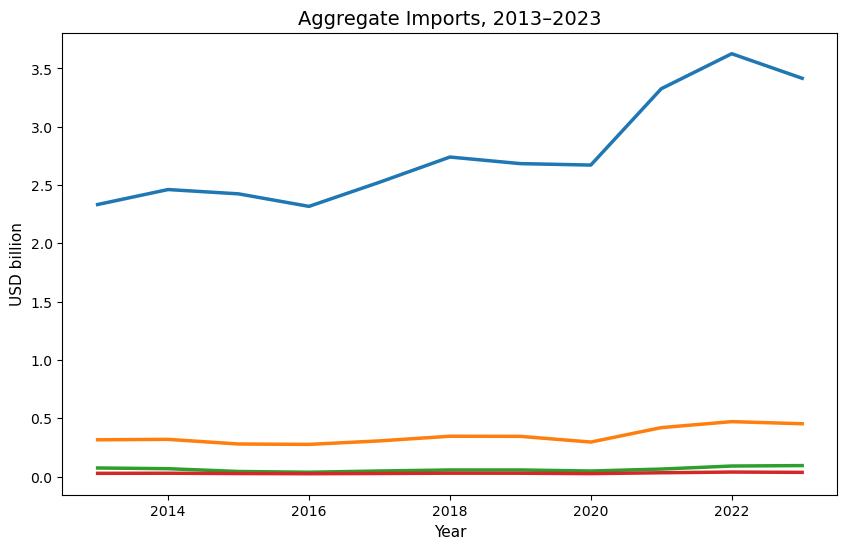

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

annual_imports = (
    df.groupby(['t', 'importer_name'], as_index=False)['v']
      .sum()
      .rename(columns={'v': 'total_imports'})
)

annual_imports['total_imports_bln'] = annual_imports['total_imports'] / 1e9

order = (
    annual_imports[annual_imports['t'] == 2023]
    .sort_values('total_imports_bln', ascending=False)['importer_name']
    .tolist()
)

plt.figure(figsize=(10, 6))

for country in order:
    temp = annual_imports[annual_imports['importer_name'] == country]
    plt.plot(temp['t'], temp['total_imports_bln'], linewidth=2.5, label=country)

plt.title('Aggregate Imports, 2013–2023', fontsize=14)
plt.xlabel('Year', fontsize=11)
plt.ylabel('USD billion', fontsize=11)

plt.grid(False)
plt.spines['top'].set_visible(False)
plt.spines['right'].set_visible(False)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'spines'

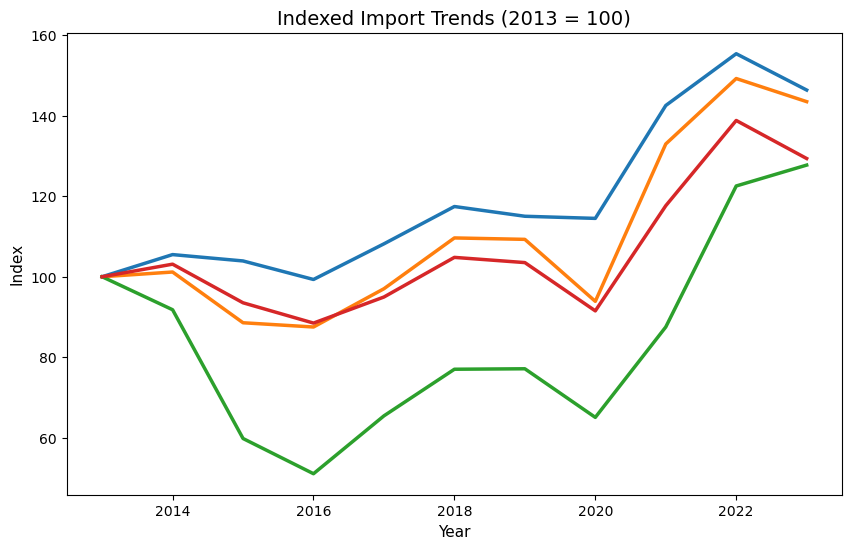

In [23]:
base = (
    annual_imports[annual_imports['t'] == 2013][['importer_name', 'total_imports']]
    .rename(columns={'total_imports': 'base_2013'})
)

annual_imports = annual_imports.merge(base, on='importer_name', how='left')
annual_imports['index_2013_100'] = annual_imports['total_imports'] / annual_imports['base_2013'] * 100

plt.figure(figsize=(10, 6))

for country in order:
    temp = annual_imports[annual_imports['importer_name'] == country]
    plt.plot(temp['t'], temp['index_2013_100'], linewidth=2.5, label=country)

plt.title('Indexed Import Trends (2013 = 100)', fontsize=14)
plt.xlabel('Year', fontsize=11)
plt.ylabel('Index', fontsize=11)

plt.grid(False)
plt.spines['top'].set_visible(False)
plt.spines['right'].set_visible(False)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'spines'

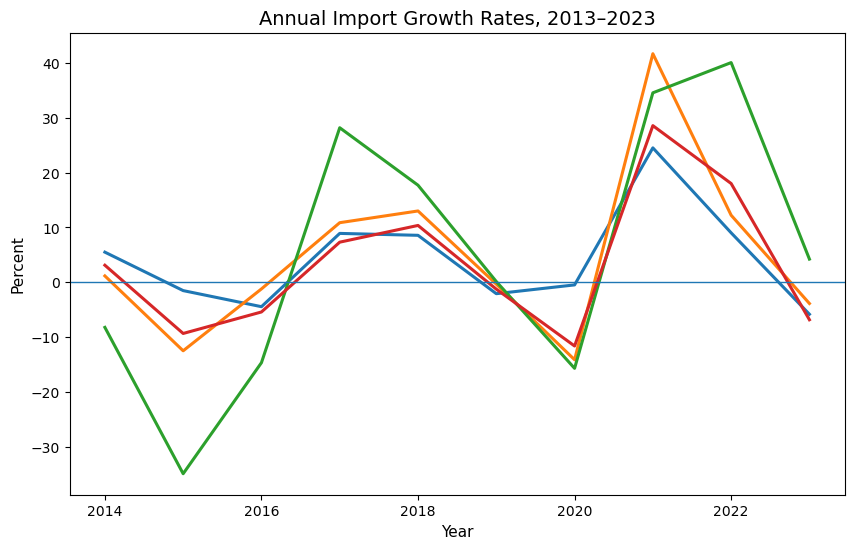

In [24]:
annual_imports = annual_imports.sort_values(['importer_name', 't']).copy()

annual_imports['growth_rate_pct'] = (
    annual_imports.groupby('importer_name')['total_imports']
    .pct_change() * 100
)

plt.figure(figsize=(10, 6))

for country in order:
    temp = annual_imports[annual_imports['importer_name'] == country]
    plt.plot(temp['t'], temp['growth_rate_pct'], linewidth=2.2, label=country)

plt.axhline(0, linewidth=1)
plt.title('Annual Import Growth Rates, 2013–2023', fontsize=14)
plt.xlabel('Year', fontsize=11)
plt.ylabel('Percent', fontsize=11)

plt.grid(False)
plt.spines['top'].set_visible(False)
plt.spines['right'].set_visible(False)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [25]:
df['k'] = df['k'].astype(str).str.zfill(6)
df['hs2'] = df['k'].str[:2]

hs2_imports = (
    df.groupby(['t', 'importer_name', 'hs2'], as_index=False)['v']
      .sum()
      .rename(columns={'v': 'imports_hs2'})
)

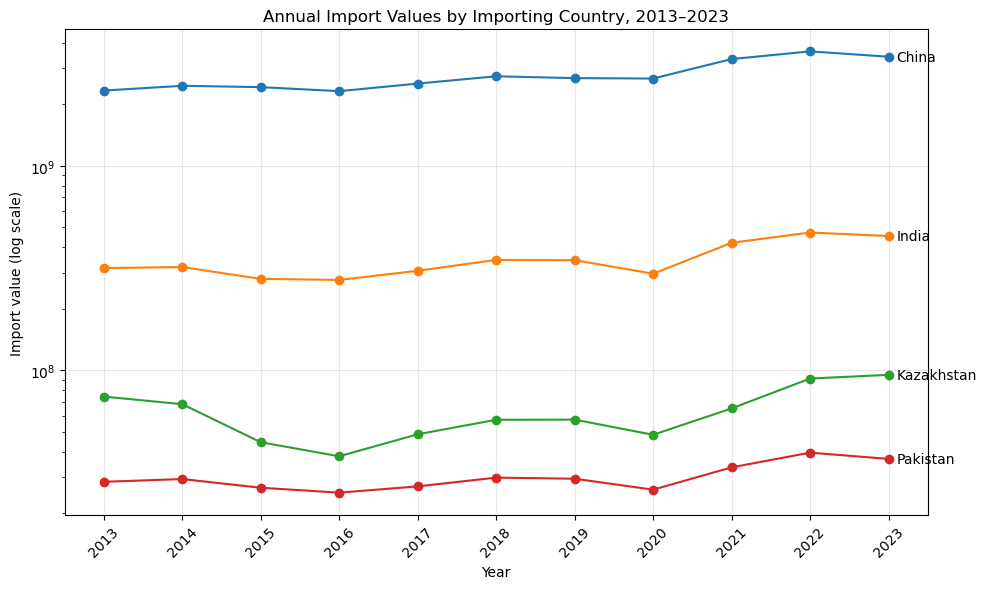

<Figure size 640x480 with 0 Axes>

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load data
data_path = Path("BACI panel.csv")
df = pd.read_csv(data_path)

# Aggregate
annual_imports = (
    df.groupby(["t", "importer_name"], as_index=False)["v"]
      .sum()
      .rename(columns={"t": "year", "v": "import_value"})
      .sort_values(["importer_name", "year"])
)

# Plot
plt.figure(figsize=(10, 6))

for importer, group in annual_imports.groupby("importer_name"):
    plt.plot(group["year"], group["import_value"], marker="o")

    # Get last point for annotation
    last_x = group["year"].iloc[-1]
    last_y = group["import_value"].iloc[-1]

    # Add country label slightly to the right
    plt.text(last_x + 0.1, last_y, importer, fontsize=10, va='center')

plt.yscale("log")
plt.title("Annual Import Values by Importing Country, 2013–2023")
plt.xlabel("Year")
plt.ylabel("Import value (log scale)")
plt.xticks(sorted(annual_imports["year"].unique()), rotation=45)

# Remove legend (labels are on lines now)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

out_dir = Path("Graphs")
chart_path = out_dir / "figure 1 annual im by country.png"
summary_path = out_dir / "chapter2_section21_annual_imports.csv"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
annual_imports.to_csv(summary_path, index=False)

In [72]:
import pandas as pd

# Load dataset
df = pd.read_csv("BACI panel.csv")

# Ensure correct column names
# i = importer code, j = exporter code, importer_name = importer name, v = trade value

# Step 1: total imports by country
total_imports = (
    df.groupby("importer_name")["v"]
    .sum()
    .rename("total_imports")
)

# Step 2: total imports by (importer, exporter)
trade_by_partner = (
    df.groupby(["importer_name", "j"])["v"]
    .sum()
    .reset_index()
)

# Step 3: merge totals
trade_by_partner = trade_by_partner.merge(
    total_imports,
    on="importer_name"
)

# Step 4: compute share
trade_by_partner["share"] = (
    trade_by_partner["v"] / trade_by_partner["total_imports"]
)

# Step 5: get top 10 exporters for each country
top10 = (
    trade_by_partner
    .sort_values(["importer_name", "v"], ascending=[True, False])
    .groupby("importer_name")
    .head(10)
)

# Step 6: print results
for country in top10["importer_name"].unique():
    print(f"\n=== {country} ===")
    
    country_data = top10[top10["importer_name"] == country]
    
    print("Total imports:", total_imports[country])
    print("\nTop 10 exporters:")
    
    print(
        country_data[["j", "v", "share"]]
        .rename(columns={
            "j": "exporter_code",
            "v": "import_value",
            "share": "share_of_total"
        })
        .to_string(index=False)
    )
    
    # Sum of top 10 share
    total_share = country_data["share"].sum()
    print(f"\nTop 10 share: {total_share:.2%}")


=== China ===
Total imports: 30522209867.495

Top 10 exporters:
 exporter_code  import_value  share_of_total
           842  5.335992e+09        0.174823
           344  2.966049e+09        0.097177
           392  1.857150e+09        0.060846
           276  1.391086e+09        0.045576
           410  1.200163e+09        0.039321
           704  8.332547e+08        0.027300
           484  8.280804e+08        0.027130
           826  8.126071e+08        0.026623
           699  7.990277e+08        0.026179
           643  6.533740e+08        0.021407

Top 10 share: 54.64%

=== India ===
Total imports: 3833917747.294

Top 10 exporters:
 exporter_code  import_value  share_of_total
           842  6.408731e+08        0.167159
           784  2.791606e+08        0.072813
           156  1.907735e+08        0.049759
           344  1.240214e+08        0.032348
           276  1.198115e+08        0.031250
           826  1.172062e+08        0.030571
            50  9.651107e+07        0.0

In [74]:
import pandas as pd

# Load dataset
df = pd.read_csv("BACI panel.csv")

# Ensure HS2 is numeric/string (depending on your data)
# If needed:
# df["hs2"] = df["hs2"].astype(str)

# Step 1: total imports by country
total_imports = (
    df.groupby("importer_name")["v"]
    .sum()
    .rename("total_imports")
)

# Step 2: imports by country and HS2 sector
sector_imports = (
    df.groupby(["importer_name", "hs2"])["v"]
    .sum()
    .reset_index()
)

# Step 3: merge totals
sector_imports = sector_imports.merge(
    total_imports,
    on="importer_name"
)

# Step 4: compute sector share
sector_imports["share"] = (
    sector_imports["v"] / sector_imports["total_imports"]
)

# Step 5: sort (largest sectors first)
sector_imports = sector_imports.sort_values(
    ["importer_name", "share"],
    ascending=[True, False]
)

# Step 6: display top sectors for each country
for country in sector_imports["importer_name"].unique():
    print(f"\n=== {country} ===")
    
    country_data = sector_imports[
        sector_imports["importer_name"] == country
    ].head(10)
    
    print(
        country_data[["hs2", "v", "share"]]
        .rename(columns={
            "hs2": "HS2_sector",
            "v": "import_value",
            "share": "share_of_total"
        })
        .to_string(index=False)
    )


=== China ===
 HS2_sector  import_value  share_of_total
         85  9.205933e+09        0.301614
         84  5.569234e+09        0.182465
         94  1.013179e+09        0.033195
         39  9.960304e+08        0.032633
         87  9.643012e+08        0.031593
         95  8.527700e+08        0.027939
         90  8.239726e+08        0.026996
         73  8.216194e+08        0.026919
         61  7.877186e+08        0.025808
         62  7.647877e+08        0.025057

=== India ===
 HS2_sector  import_value  share_of_total
         27  4.920401e+08        0.128339
         71  4.485160e+08        0.116986
         84  2.381794e+08        0.062124
         29  2.097214e+08        0.054702
         30  2.040840e+08        0.053231
         87  1.953793e+08        0.050961
         85  1.906471e+08        0.049726
         72  1.355199e+08        0.035348
         10  1.121462e+08        0.029251
         62  9.728835e+07        0.025376

=== Kazakhstan ===
 HS2_sector  import_value 

In [75]:
df = pd.read_csv('Full Tariffs final.csv')
df

,iso3_reporter,iso3_exporter,Year,ProductCode,mfn,mfnAVE,pref,prefAVE,Applied_Tariff,Applied_Tariff_AVE
0,CHN,AFG,2013,10121,0.0,0.0,0.0,0.0,0.0,0.0
1,CHN,AFG,2013,10129,10.0,10.0,0.0,0.0,0.0,0.0
2,CHN,AFG,2013,10130,5.0,5.0,0.0,0.0,0.0,0.0
3,CHN,AFG,2013,10190,10.0,10.0,0.0,0.0,0.0,0.0
4,CHN,AFG,2013,10221,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
20941264,PAK,PAK,2023,970200,3.0,3.0,5.0,5.0,3.0,3.0
20941265,PAK,PAK,2023,970300,3.0,3.0,5.0,5.0,3.0,3.0
20941266,PAK,PAK,2023,970400,3.0,3.0,5.0,5.0,3.0,3.0
20941267,PAK,PAK,2023,970500,3.0,3.0,5.0,5.0,3.0,3.0


In [76]:
# check how many same-country rows you have
same_country_mask = df['iso3_reporter'] == df['iso3_exporter']
print("Rows with reporter == exporter:", same_country_mask.sum())

# drop them
df = df.loc[~same_country_mask].copy()

# verify
print("New shape:", df.shape)
print("Remaining same-country rows:", (df['iso3_reporter'] == df['iso3_exporter']).sum())

Rows with reporter == exporter: 238644
New shape: (20702625, 10)
Remaining same-country rows: 0


In [77]:
df.to_csv("Full Tariffs final.csv", index=False)

In [78]:
df = pd.read_csv('Full Tariffs final.csv')
df

,iso3_reporter,iso3_exporter,Year,ProductCode,mfn,mfnAVE,pref,prefAVE,Applied_Tariff,Applied_Tariff_AVE
0,CHN,AFG,2013,10121,0.0,0.0,0.0,0.0,0.0,0.0
1,CHN,AFG,2013,10129,10.0,10.0,0.0,0.0,0.0,0.0
2,CHN,AFG,2013,10130,5.0,5.0,0.0,0.0,0.0,0.0
3,CHN,AFG,2013,10190,10.0,10.0,0.0,0.0,0.0,0.0
4,CHN,AFG,2013,10221,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
20702620,PAK,NPL,2023,970200,3.0,3.0,5.0,5.0,3.0,3.0
20702621,PAK,NPL,2023,970300,3.0,3.0,5.0,5.0,3.0,3.0
20702622,PAK,NPL,2023,970400,3.0,3.0,5.0,5.0,3.0,3.0
20702623,PAK,NPL,2023,970500,3.0,3.0,5.0,5.0,3.0,3.0


# import pandas as pd
import numpy as np

# keep a working copy
tariff = df.copy()

# basic checks
print(tariff.shape)
print(tariff[['mfn', 'pref', 'Applied_Tariff']].isna().sum())

# summary statistics
summary_stats = tariff[['mfn', 'pref', 'Applied_Tariff']].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).T
summary_stats

In [80]:
tariff['pref_available'] = tariff['pref'].notna().astype(int)
tariff['preference_used'] = ((tariff['Applied_Tariff'] < tariff['mfn']) & tariff['Applied_Tariff'].notna() & tariff['mfn'].notna()).astype(int)
tariff['preference_margin'] = tariff['mfn'] - tariff['Applied_Tariff']

# overall preference indicators
pref_indicators = {
    'share_pref_available': tariff['pref_available'].mean(),
    'share_preference_used': tariff['preference_used'].mean(),
    'avg_preference_margin': tariff['preference_margin'].mean(),
    'median_preference_margin': tariff['preference_margin'].median()
}

print(pref_indicators)

{'share_pref_available': np.float64(0.9993817209170335), 'share_preference_used': np.float64(0.7187112262333882), 'avg_preference_margin': np.float64(6.009199454696674), 'median_preference_margin': 4.0}


In [86]:
# import pandas as pd
import numpy as np

# keep a working copy
tariff = df.copy()

# basic checks
print(tariff.shape)
print(tariff[['mfn', 'pref', 'Applied_Tariff']].isna().sum())

# summary statistics
summary_stats = tariff[['mfn', 'pref', 'Applied_Tariff']].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).T
summary_stats

(20702625, 10)
mfn                1040
pref              12800
Applied_Tariff        0
dtype: int64


,count,mean,std,min,25%,50%,75%,90%,95%,max
mfn,20701585.0,9.218137,9.658193,0.0,5.0,7.50,10.00,16.67,26.67,150.0
pref,20689825.0,5.037158,8.932017,0.0,0.0,1.88,8.67,11.25,15.00,90.0
Applied_Tariff,20702625.0,3.209556,5.214486,0.0,0.0,0.00,5.00,10.00,11.25,125.0


In [81]:
yearly_tariffs = tariff.groupby('Year').agg(
    mean_mfn=('mfn', 'mean'),
    median_mfn=('mfn', 'median'),
    mean_applied=('Applied_Tariff', 'mean'),
    median_applied=('Applied_Tariff', 'median'),
    obs=('Applied_Tariff', 'size')
).reset_index()

yearly_tariffs

,Year,mean_mfn,median_mfn,mean_applied,median_applied,obs
0,2013,10.056933,9.75,3.476087,0.0,2027065
1,2014,9.735230,8.00,3.419288,0.0,2027065
2,2015,9.445793,7.50,3.347910,0.0,2027065
3,2016,9.198653,7.50,3.246963,0.0,2027065
4,2017,9.204898,7.50,3.240525,0.0,1801971
5,2018,9.190671,7.50,3.223270,0.0,1801971
6,2019,9.239148,7.50,3.183266,0.0,1801971
7,2020,8.800654,7.50,3.042606,0.0,1801971
8,2021,8.653914,7.00,2.963970,0.0,1801971
9,2022,8.995224,7.50,3.101750,0.0,1792255


In [82]:
reporter_tariffs = tariff.groupby('iso3_reporter').agg(
    mean_mfn=('mfn', 'mean'),
    mean_applied=('Applied_Tariff', 'mean'),
    median_applied=('Applied_Tariff', 'median'),
    share_preference_used=('preference_used', 'mean'),
    obs=('Applied_Tariff', 'size')
).reset_index().sort_values('mean_applied', ascending=False)

reporter_tariffs

,iso3_reporter,mean_mfn,mean_applied,median_applied,share_preference_used,obs
3,PAK,11.861335,4.030418,5.0,0.619480,417613
1,IND,14.013094,3.728851,0.0,0.833847,5729944
2,KAZ,6.869567,3.699537,2.5,0.604225,11154737
0,CHN,8.518986,0.626296,0.0,0.912453,3400331


In [94]:
##### import pandas as pd
import numpy as np

# working copy
tariff = df.copy()

# make sure product code is string and preserve leading zeros
tariff['ProductCode'] = tariff['ProductCode'].astype(str).str.strip()

# convert 5-digit codes to 6-digit by padding on the left if needed
tariff['ProductCode'] = tariff['ProductCode'].str.zfill(6)

# create HS2 code
tariff['hs2'] = tariff['ProductCode'].str[:2]

# aggregate tariffs to HS2 level
# here I use the mean applied tariff across product-country-year observations within each reporter-hs2
hs2_agg = (
    tariff
    .groupby(['iso3_reporter', 'hs2'], as_index=False)
    .agg(
        mean_applied_tariff=('Applied_Tariff', 'mean'),
        median_applied_tariff=('Applied_Tariff','median'),
        mean_mfn=('mfn', 'mean'),
        mean_pref=('pref', 'mean'),
        n_obs=('Applied_Tariff', 'size')
    )
)

# for each country, keep the 3 HS2 groups with the highest mean applied tariff
top3_hs2_by_country = (
    hs2_agg
    .sort_values(['iso3_reporter', 'mean_applied_tariff', 'median_applied_tariff'], ascending=[True, False, False])
    .groupby('iso3_reporter', as_index=False)
    .head(5)
    .copy()
)

# rank within each country
top3_hs2_by_country['rank'] = (
    top3_hs2_by_country
    .groupby('iso3_reporter')['mean_applied_tariff']
    .rank(method='first', ascending=False)
    .astype(int)
)

# final ordering
top3_hs2_by_country = top3_hs2_by_country[
    ['iso3_reporter', 'rank', 'hs2', 'mean_applied_tariff','median_applied_tariff', 'mean_mfn', 'mean_pref', 'n_obs']
].sort_values(['iso3_reporter', 'rank'])

top3_simple = top3_hs2_by_country[
    ['iso3_reporter', 'rank', 'hs2', 'mean_applied_tariff', 'median_applied_tariff']
].sort_values(['iso3_reporter', 'rank'])

print(top3_simple)

    iso3_reporter  rank hs2  mean_applied_tariff  median_applied_tariff
23            CHN     1  24             6.180254                   0.00
10            CHN     2  11             2.809553                   0.00
85            CHN     3  87             1.729916                   0.00
20            CHN     4  21             1.375841                   0.00
66            CHN     5  67             1.230391                   0.00
105           IND     1  09            22.415025                  25.50
102           IND     2  06            21.899163                   5.00
194           IND     3  99            20.734211                   0.00
104           IND     4  08            14.288562                   0.00
107           IND     5  11            13.968662                   0.00
260           KAZ     1  66             9.837863                  10.00
255           KAZ     2  61             9.452337                  10.00
259           KAZ     3  65             9.442240                

In [84]:
top3_wide = (
    top3_simple
    .pivot(index='iso3_reporter', columns='rank', values=['hs2', 'mean_applied_tariff'])
)

top3_wide.columns = [
    f'{var}_top{rank}' for var, rank in top3_wide.columns
]

top3_wide = top3_wide.reset_index()

print(top3_wide)

  iso3_reporter hs2_top1 hs2_top2 hs2_top3 mean_applied_tariff_top1  \
0           CHN       24       11       87                 6.180254   
1           IND       09       06       99                22.415025   
2           KAZ       66       61       65                 9.837863   
3           PAK       69       63       95                 6.399978   

  mean_applied_tariff_top2 mean_applied_tariff_top3  
0                 2.809553                 1.729916  
1                21.899163                20.734211  
2                 9.452337                  9.44224  
3                 5.250569                 5.166124  


In [2]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.


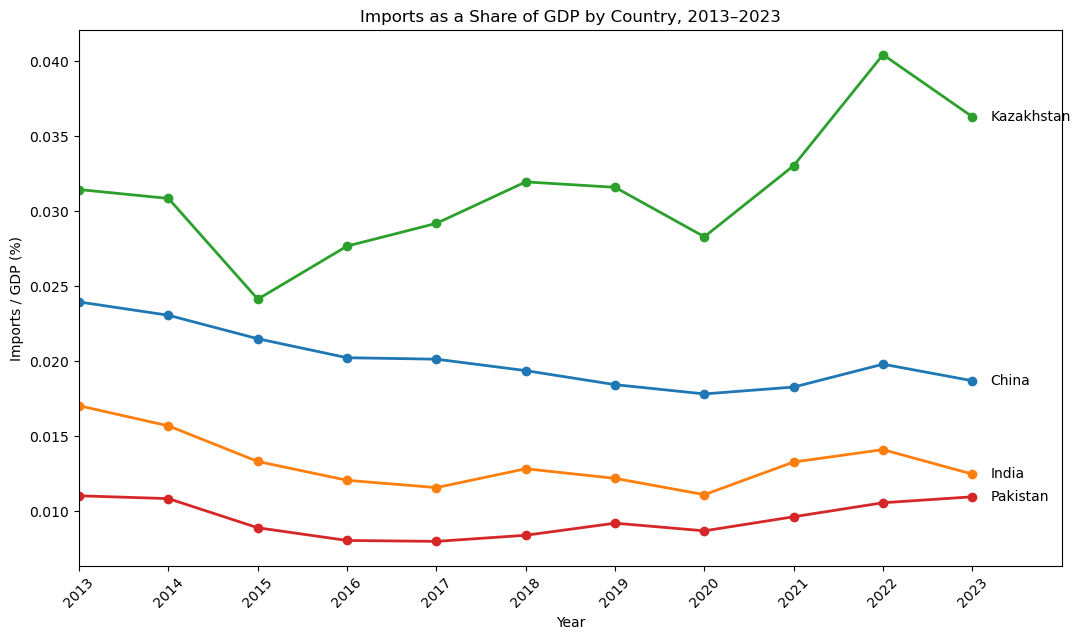

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# --- LOAD DATA ---

# Adjust file names if needed
baci = pd.read_csv("BACI panel.csv")
gdp_raw = pd.read_excel("World Bank GDP current USD.xls")

# --- PREPARE IMPORTS ---

imports = (
    baci.groupby(["t", "importer_name"], as_index=False)["v"]
        .sum()
        .rename(columns={"t": "year", "v": "imports"})
)

# --- PREPARE GDP (World Bank format) ---

# Keep only your countries
countries = ["China", "India", "Pakistan", "Kazakhstan"]
gdp = gdp_raw[gdp_raw["Country Name"].isin(countries)]

# Convert wide → long
gdp_long = gdp.melt(
    id_vars=["Country Name"],
    var_name="year",
    value_name="gdp"
)

# Keep only numeric years
gdp_long = gdp_long[gdp_long["year"].astype(str).str.isnumeric()]
gdp_long["year"] = gdp_long["year"].astype(int)

# Filter period
gdp_long = gdp_long[(gdp_long["year"] >= 2013) & (gdp_long["year"] <= 2023)]

# Rename for merge
gdp_long = gdp_long.rename(columns={"Country Name": "importer_name"})

# --- MERGE ---

df = imports.merge(gdp_long, on=["year", "importer_name"], how="left")

# --- COMPUTE RATIO ---

df["import_gdp_percent"] = (df["imports"] / df["gdp"]) * 100

# --- PLOT ---

plt.figure(figsize=(11, 6.5))

for country, group in df.groupby("importer_name"):
    group = group.sort_values("year")
    
    plt.plot(group["year"], group["import_gdp_percent"], marker="o", linewidth=2)
    
    # Label at the end
    last_x = group["year"].iloc[-1]
    last_y = group["import_gdp_percent"].iloc[-1]
    
    plt.text(last_x + 0.2, last_y, country, va="center", fontsize=10)

plt.title("Imports as a Share of GDP by Country, 2013–2023")
plt.xlabel("Year")
plt.ylabel("Imports / GDP (%)")
plt.xticks(sorted(df["year"].unique()), rotation=45)

plt.grid(False)
plt.xlim(df["year"].min(), df["year"].max() + 1)

plt.tight_layout()

# --- SAVE ---
plt.savefig("import_gdp_ratio.png", dpi=220, bbox_inches="tight")

plt.show()

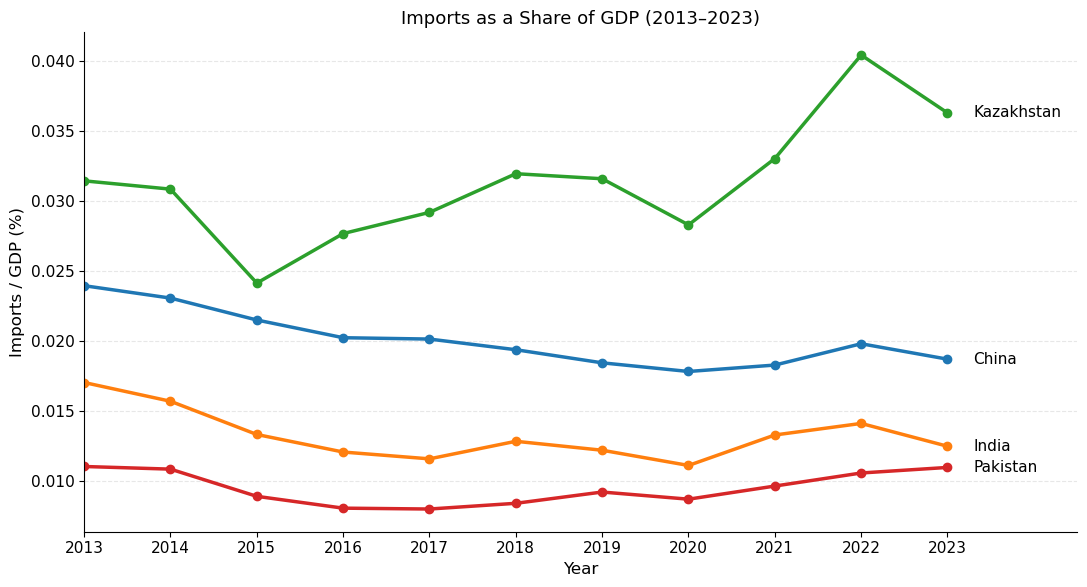

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
baci = pd.read_csv("BACI panel.csv")
gdp_raw = pd.read_excel("World Bank GDP current USD.xls")

# --- Prepare imports ---
imports = (
    baci.groupby(["t", "importer_name"], as_index=False)["v"]
        .sum()
        .rename(columns={"t": "year", "v": "imports"})
)

# --- Prepare GDP ---
countries = ["China", "India", "Pakistan", "Kazakhstan"]
gdp = gdp_raw[gdp_raw["Country Name"].isin(countries)]

gdp_long = gdp.melt(
    id_vars=["Country Name"],
    var_name="year",
    value_name="gdp"
)

gdp_long = gdp_long[gdp_long["year"].astype(str).str.isnumeric()]
gdp_long["year"] = gdp_long["year"].astype(int)
gdp_long = gdp_long[(gdp_long["year"] >= 2013) & (gdp_long["year"] <= 2023)]

gdp_long = gdp_long.rename(columns={"Country Name": "importer_name"})

# --- Merge ---
df = imports.merge(gdp_long, on=["year", "importer_name"], how="left")
df["import_gdp_percent"] = (df["imports"] / df["gdp"]) * 100

# --- Styling ---
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12
})

fig, ax = plt.subplots(figsize=(11, 6))

# Plot lines
for country, group in df.groupby("importer_name"):
    group = group.sort_values("year")
    
    ax.plot(
        group["year"],
        group["import_gdp_percent"],
        linewidth=2.5,
        marker="o"
    )
    
    # Label at end
    last_x = group["year"].iloc[-1]
    last_y = group["import_gdp_percent"].iloc[-1]
    
    ax.text(
        last_x + 0.3,
        last_y,
        country,
        va="center",
        fontsize=11
    )

# Titles and labels
ax.set_title("Imports as a Share of GDP (2013–2023)")
ax.set_xlabel("Year")
ax.set_ylabel("Imports / GDP (%)")

# Clean axis
ax.set_xticks(range(2013, 2024))
ax.set_xlim(2013, 2024.5)

# Remove unnecessary spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Optional: subtle horizontal guide lines
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.xaxis.grid(False)

fig.tight_layout()

# Save
plt.savefig("import_gdp_ratio_professional.png", dpi=300, bbox_inches="tight")

plt.show()

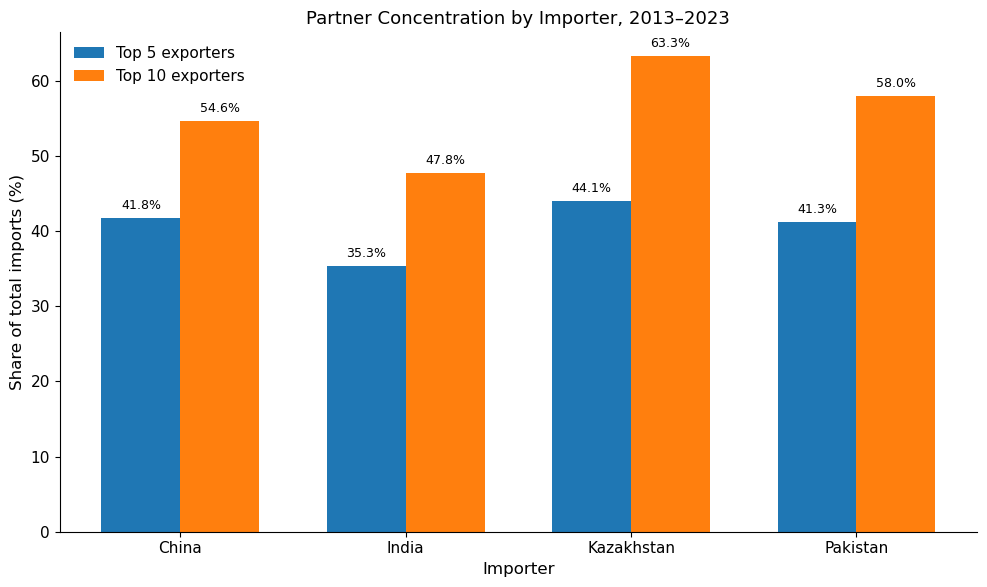

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load BACI data
baci = pd.read_csv("BACI panel.csv")

# Aggregate imports by importer-exporter pair
partner_imports = (
    baci.groupby(["importer_name", "j"], as_index=False)["v"]
        .sum()
        .rename(columns={"v": "import_value"})
)

# Total imports by importer
totals = (
    partner_imports.groupby("importer_name", as_index=False)["import_value"]
        .sum()
        .rename(columns={"import_value": "total_imports"})
)

# Merge totals
partner_imports = partner_imports.merge(totals, on="importer_name", how="left")

# Sort exporters within each importer
partner_imports = partner_imports.sort_values(
    ["importer_name", "import_value"],
    ascending=[True, False]
)

# Rank exporters
partner_imports["rank"] = partner_imports.groupby("importer_name").cumcount() + 1

# Compute top-5 and top-10 shares
top5 = (
    partner_imports[partner_imports["rank"] <= 5]
    .groupby("importer_name", as_index=False)["import_value"]
    .sum()
    .rename(columns={"import_value": "top5_imports"})
)

top10 = (
    partner_imports[partner_imports["rank"] <= 10]
    .groupby("importer_name", as_index=False)["import_value"]
    .sum()
    .rename(columns={"import_value": "top10_imports"})
)

shares = totals.merge(top5, on="importer_name").merge(top10, on="importer_name")
shares["top5_share"] = shares["top5_imports"] / shares["total_imports"] * 100
shares["top10_share"] = shares["top10_imports"] / shares["total_imports"] * 100

# Order countries
country_order = ["China", "India", "Kazakhstan", "Pakistan"]
shares["importer_name"] = pd.Categorical(
    shares["importer_name"],
    categories=country_order,
    ordered=True
)
shares = shares.sort_values("importer_name")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(shares))
width = 0.35

ax.bar(
    [i - width/2 for i in x],
    shares["top5_share"],
    width=width,
    label="Top 5 exporters"
)

ax.bar(
    [i + width/2 for i in x],
    shares["top10_share"],
    width=width,
    label="Top 10 exporters"
)

# Labels above bars
for i, val in enumerate(shares["top5_share"]):
    ax.text(i - width/2, val + 0.8, f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

for i, val in enumerate(shares["top10_share"]):
    ax.text(i + width/2, val + 0.8, f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

# Style
ax.set_title("Partner Concentration by Importer, 2013–2023")
ax.set_ylabel("Share of total imports (%)")
ax.set_xlabel("Importer")
ax.set_xticks(list(x))
ax.set_xticklabels(shares["importer_name"])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

ax.legend(frameon=False)
plt.tight_layout()

# Save
plt.savefig("partner_concentration_top5_top10.png", dpi=300, bbox_inches="tight")
plt.show()

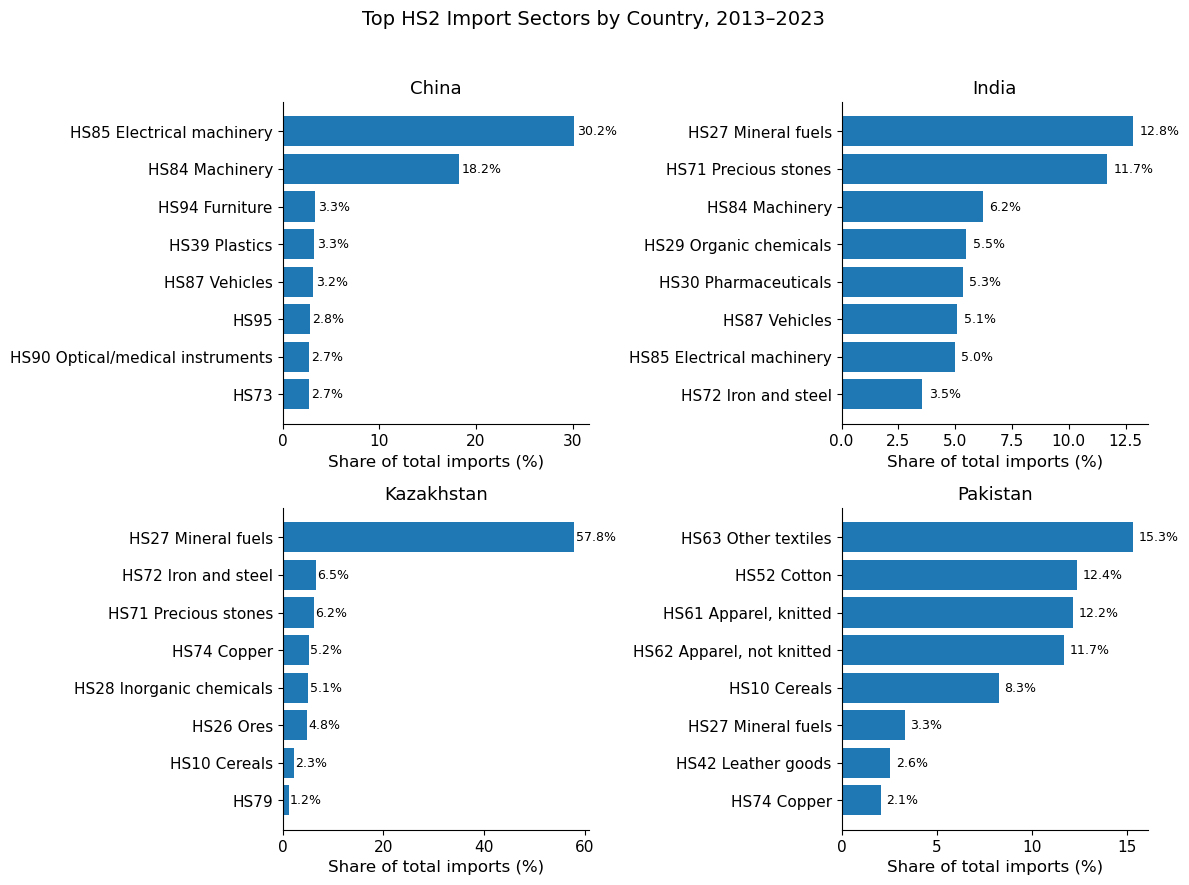

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("BACI panel.csv")

# Aggregate imports by importer and HS2
hs2 = (
    df.groupby(["importer_name", "hs2"], as_index=False)["v"]
      .sum()
      .rename(columns={"v": "import_value"})
)

# Total imports by country
totals = (
    hs2.groupby("importer_name", as_index=False)["import_value"]
       .sum()
       .rename(columns={"import_value": "total_imports"})
)

# Merge totals and compute shares
hs2 = hs2.merge(totals, on="importer_name", how="left")
hs2["share"] = hs2["import_value"] / hs2["total_imports"] * 100

# Optional HS2 labels dictionary
hs2_labels = {
    27: "HS27 Mineral fuels",
    71: "HS71 Precious stones",
    84: "HS84 Machinery",
    85: "HS85 Electrical machinery",
    87: "HS87 Vehicles",
    39: "HS39 Plastics",
    90: "HS90 Optical/medical instruments",
    94: "HS94 Furniture",
    52: "HS52 Cotton",
    61: "HS61 Apparel, knitted",
    62: "HS62 Apparel, not knitted",
    63: "HS63 Other textiles",
    72: "HS72 Iron and steel",
    74: "HS74 Copper",
    10: "HS10 Cereals",
    29: "HS29 Organic chemicals",
    30: "HS30 Pharmaceuticals",
    42: "HS42 Leather goods",
    8:  "HS08 Fruit and nuts",
    26: "HS26 Ores",
    28: "HS28 Inorganic chemicals",
}

def hs2_name(x):
    try:
        x_int = int(x)
        return hs2_labels.get(x_int, f"HS{x_int:02d}")
    except:
        return str(x)

# Country order
countries = ["China", "India", "Kazakhstan", "Pakistan"]

# Create 2x2 panel
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, country in zip(axes, countries):
    country_data = (
        hs2[hs2["importer_name"] == country]
        .sort_values("share", ascending=False)
        .head(8)
        .copy()
    )

    country_data = country_data.sort_values("share", ascending=True)
    country_data["label"] = country_data["hs2"].apply(hs2_name)

    ax.barh(country_data["label"], country_data["share"])
    ax.set_title(country)
    ax.set_xlabel("Share of total imports (%)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    # value labels
    for i, v in enumerate(country_data["share"]):
        ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)

fig.suptitle("Top HS2 Import Sectors by Country, 2013–2023", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("hs2_top_sectors_by_country_panels.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
pip install squarify

Note: you may need to restart the kernel to use updated packages.


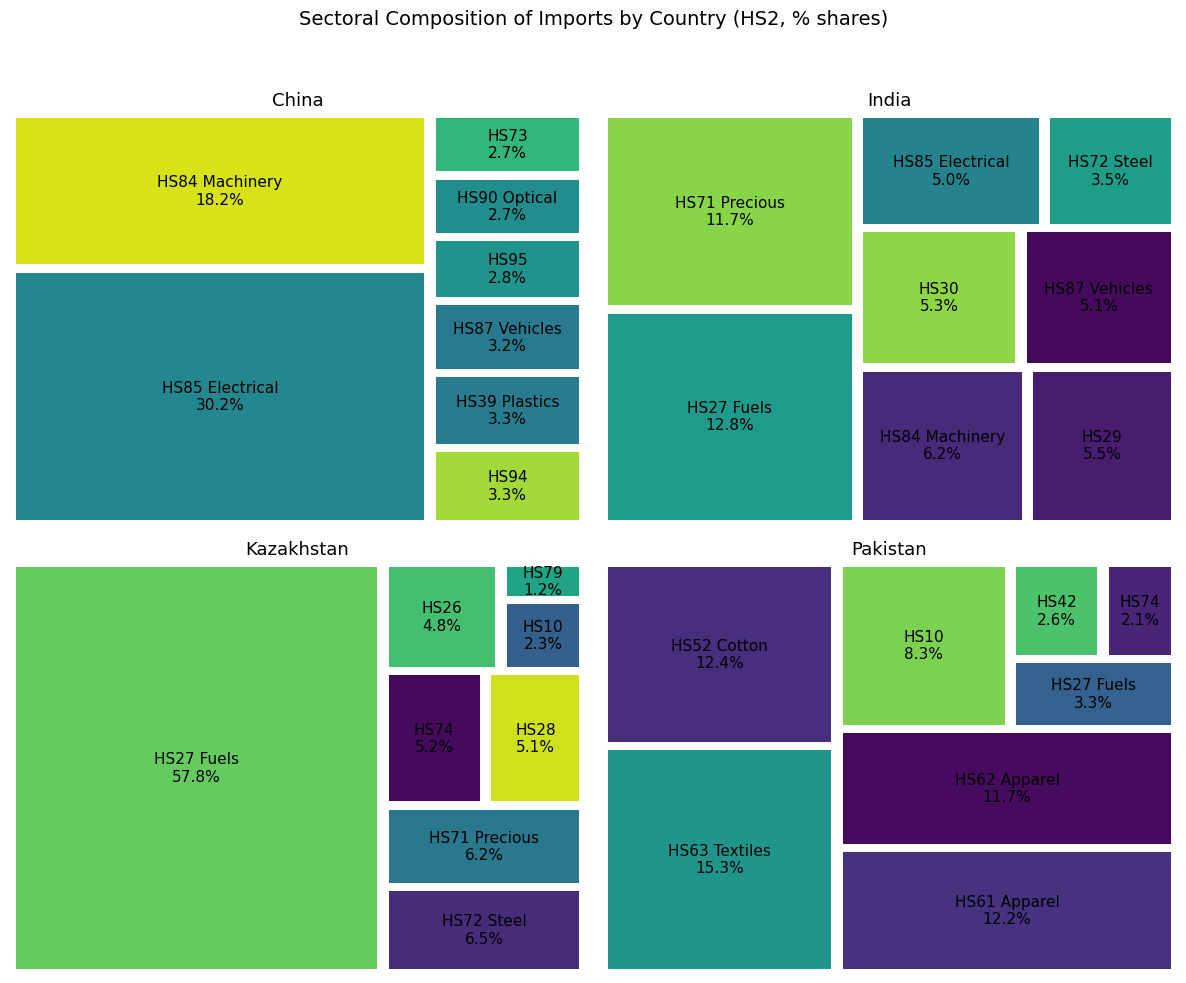

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import squarify

# Load data
df = pd.read_csv("BACI panel.csv")

# Aggregate imports by HS2
hs2 = (
    df.groupby(["importer_name", "hs2"], as_index=False)["v"]
      .sum()
      .rename(columns={"v": "import_value"})
)

# Total imports by country
totals = (
    hs2.groupby("importer_name", as_index=False)["import_value"]
       .sum()
       .rename(columns={"import_value": "total_imports"})
)

# Merge and compute shares
hs2 = hs2.merge(totals, on="importer_name")
hs2["share"] = hs2["import_value"] / hs2["total_imports"] * 100

# HS2 labels (extend if needed)
labels_dict = {
    27: "HS27 Fuels",
    84: "HS84 Machinery",
    85: "HS85 Electrical",
    87: "HS87 Vehicles",
    39: "HS39 Plastics",
    90: "HS90 Optical",
    71: "HS71 Precious",
    72: "HS72 Steel",
    52: "HS52 Cotton",
    61: "HS61 Apparel",
    62: "HS62 Apparel",
    63: "HS63 Textiles"
}

def label_name(x):
    try:
        x = int(x)
        return labels_dict.get(x, f"HS{x:02d}")
    except:
        return str(x)

countries = ["China", "India", "Kazakhstan", "Pakistan"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, country in zip(axes, countries):
    data = (
        hs2[hs2["importer_name"] == country]
        .sort_values("share", ascending=False)
        .head(8)
    )

    sizes = data["share"].values
    labels = [f"{label_name(h)}\n{share:.1f}%" 
              for h, share in zip(data["hs2"], data["share"])]

    squarify.plot(
        sizes=sizes,
        label=labels,
        ax=ax,
        pad=True
    )

    ax.set_title(country)
    ax.axis("off")

fig.suptitle("Sectoral Composition of Imports by Country (HS2, % shares)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("hs2_treemap_by_country.png", dpi=300, bbox_inches="tight")
plt.show()

TypeError: matplotlib.axes._axes.Axes.text() got multiple values for keyword argument 'ha'

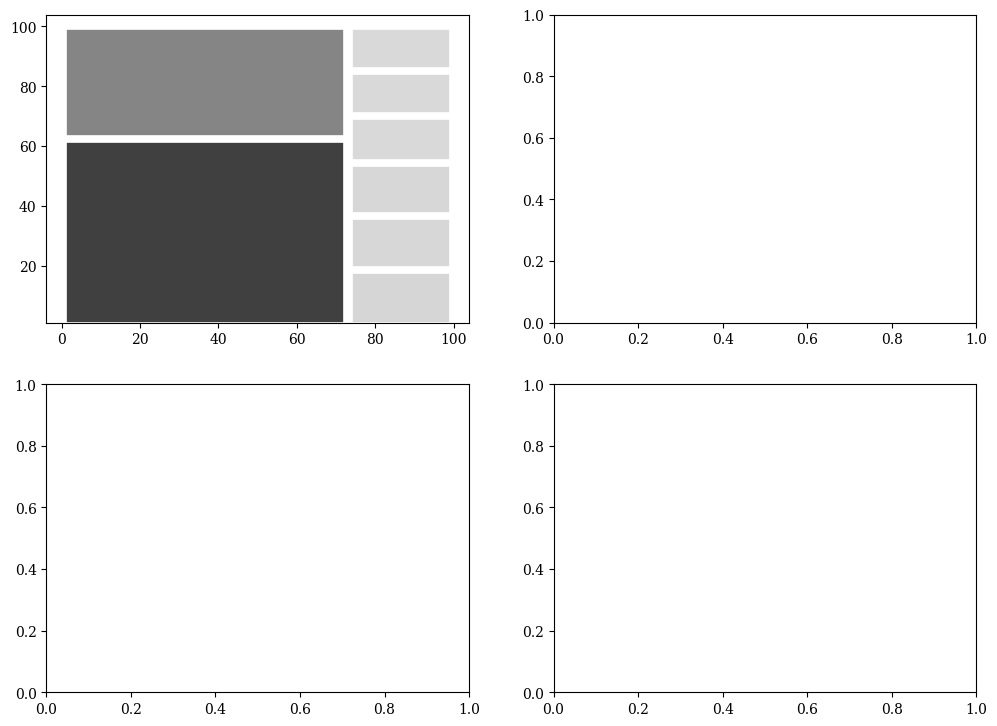

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import squarify
import matplotlib.colors as mcolors

# -----------------------------
# 1. Load and prepare the data
# -----------------------------
df = pd.read_csv("BACI panel.csv")

hs2 = (
    df.groupby(["importer_name", "hs2"], as_index=False)["v"]
      .sum()
      .rename(columns={"v": "import_value"})
)

totals = (
    hs2.groupby("importer_name", as_index=False)["import_value"]
       .sum()
       .rename(columns={"import_value": "total_imports"})
)

hs2 = hs2.merge(totals, on="importer_name", how="left")
hs2["share"] = hs2["import_value"] / hs2["total_imports"] * 100

# -----------------------------
# 2. HS2 labels
# -----------------------------
hs2_labels = {
    27: "HS27 Fuels",
    84: "HS84 Machinery",
    85: "HS85 Electrical",
    87: "HS87 Vehicles",
    39: "HS39 Plastics",
    90: "HS90 Optical",
    94: "HS94 Furniture",
    71: "HS71 Precious",
    72: "HS72 Steel",
    74: "HS74 Copper",
    52: "HS52 Cotton",
    61: "HS61 Apparel",
    62: "HS62 Apparel",
    63: "HS63 Textiles",
    10: "HS10 Cereals",
    28: "HS28 Inorganic",
    29: "HS29 Chemicals",
    30: "HS30 Pharma",
    42: "HS42 Leather",
    26: "HS26 Ores",
    79: "HS79 Zinc",
    8:  "HS08 Fruit",
    95: "HS95 Toys",
    11: "HS11 Milling"
}

def format_hs2_label(hs2_code):
    try:
        hs2_code = int(hs2_code)
        return hs2_labels.get(hs2_code, f"HS{hs2_code:02d}")
    except Exception:
        return str(hs2_code)

# -----------------------------
# 3. Journal-style settings
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "figure.titlesize": 14
})

countries = ["China", "India", "Kazakhstan", "Pakistan"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8.8), facecolor="white")
axes = axes.flatten()

for ax, country in zip(axes, countries):
    data = (
        hs2[hs2["importer_name"] == country]
        .sort_values("share", ascending=False)
        .head(8)   # fewer boxes = cleaner journal style
        .copy()
    )

    sizes = data["share"].values

    # Monochrome palette: restrained and publication-style
    cmap = plt.cm.Greys
    norm = mcolors.Normalize(vmin=min(sizes), vmax=max(sizes))
    # avoid extremes so boxes do not become pure white or too dark
    colors = [cmap(0.25 + 0.55 * norm(v)) for v in sizes]

    # Show labels only for meaningful sectors
    labels = []
    for hs, share in zip(data["hs2"], data["share"]):
        if share >= 5:
            labels.append(f"{format_hs2_label(hs)}\n{share:.1f}%")
        else:
            labels.append("")

    squarify.plot(
        sizes=sizes,
        label=labels,
        color=colors,
        pad=True,
        ax=ax,
        bar_kwargs={
            "edgecolor": "white",
            "linewidth": 1.2
        },
        text_kwargs={
            "fontsize": 8,
            "color": "black",
            "ha": "center",
            "va": "center"
        }
    )

    ax.set_title(country, pad=8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

fig.suptitle("Sectoral Composition of Imports by Country (HS2 Shares, 2013–2023)", y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("hs2_treemap_qje_style.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()